In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skfuzzy as fuzz

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from umap import UMAP

from transformers import AutoTokenizer, AutoModel, logging as hf_logging
import torch

from metrics_utils import *
from preprocessing_utils import ensure_nltk_resources, preprocess_texts

ensure_nltk_resources()
hf_logging.set_verbosity_error()

seed = 42
np.random.seed(seed)

/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/bernardod/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/bernardod/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df = pd.read_csv("../datasets/new/papers_20230217-20260217_Condensed_Matter_Superconductivity.csv", dtype=str)

In [3]:
df.head(1)

,arxiv_id,authors,updated,pdf_link,main_category,categories,title,abstract,published,link
0,2510.13098v1,['Hideo Aoki'],2025-10-15 02:33:02+00:00,https://arxiv.org/pdf/2510.13098v1,Superconductivity,"['Superconductivity', 'Strongly Correlated Ele...",Flat bands in condensed-matter systems -- pers...,There is a recent upsurge of interests in flat...,2025-10-15 02:33:02+00:00,http://arxiv.org/abs/2510.13098v1


In [4]:
CONFIG = {
    "title_column": "title",
    "abstract_column": "abstract",

    "vectorizers_to_run": ["tfidf", "sentence-transformers/all-MiniLM-L6-v2", "allenai/scibert_scivocab_uncased"],

    "tfidf": dict(min_df=3, max_df=0.7, max_features=3000, ngram_range=(1, 3)),
    "svd_components": [5, 10, 15, 20, 25, 30, 35, 50, 75],
    "use_svd": True,

    "K_values": [3, 4, 5, 6, 7, 8, 9, 10, 12, 15],
    "algorithms": ["fcm", "kmeans", "agglomerative"],
}

In [5]:
texts = (df[CONFIG["title_column"]] + " " + df[CONFIG["abstract_column"]]).tolist()
texts_clean = preprocess_texts(texts, use_pos=True)

In [6]:
def tfidf_vectorize(texts):
    vectorizer = TfidfVectorizer(
        ngram_range=CONFIG["tfidf"]["ngram_range"],
        min_df=CONFIG["tfidf"]["min_df"],
        max_df=CONFIG["tfidf"]["max_df"],
        max_features=CONFIG["tfidf"]["max_features"],
        stop_words="english",
    )
    return vectorizer.fit_transform(texts)

def sentence_transformers_vectorize(model_name, texts):
    model = SentenceTransformer(model_name)
    X = model.encode(texts, show_progress_bar=True)
    X = normalize(X, norm="l2")
    return X

model_cache = {}
def bert_vectorize(texts, model_name, batch_size=32):
    if not model_name in model_cache:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name)
        model_cache[model_name] = (tokenizer, model)
    else:
        tokenizer, model = model_cache[model_name]

    model.eval()
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)
        
        with torch.inference_mode():
            output = model(**encoded, return_dict=True)
        
        attention_mask = encoded["attention_mask"]
        token_embeddings = output.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        embeddings = (token_embeddings * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)
        
        all_embeddings.append(embeddings.cpu().numpy())
    
    X = np.vstack(all_embeddings)
    X = normalize(X, norm="l2")
    return X

In [7]:
def vectorize(vec_name, texts_clean):
    if vec_name == "tfidf":
        return tfidf_vectorize(texts_clean)
    elif "sentence-transformers" in vec_name:
        return sentence_transformers_vectorize(vec_name, texts_clean)
    else:
        return bert_vectorize(texts_clean, vec_name)

In [8]:
def build_X(X_base, n_comp=None, use_svd=False):
    """
    Returns final X that all algorithms will use.
    - If use_svd=False: returns dense array (Assumes it's already normalized).
    - Se use_svd=True: apply SVD with n_comp.
    """

    if not use_svd:
        return X_base.toarray() if hasattr(X_base, "toarray") else np.asarray(X_base)
    
    svd = TruncatedSVD(n_components=n_comp, random_state=seed)
    X = svd.fit_transform(X_base)
    X = normalize(X, norm="l2")
    return X

In [9]:
def cluster_fcm(X, K, m=1.7, error=0.005, maxiter=1000):
    cntr, U, *_rest, fpc = fuzz.cluster.cmeans(
        X.T, c=K, m=m, error=error, maxiter=maxiter,
        metric="cosine", seed=seed
    )
    U = U.T
    labels = U.argmax(axis=1)
    return labels, {"fpc": float(fpc), "U": U}

def cluster_kmeans(X, K, max_iter=300):
    model = KMeans(n_clusters=K, random_state=seed, init="k-means++", max_iter=max_iter)
    labels = model.fit_predict(X)
    return labels, {"inertia": float(model.inertia_)}

def cluster_agglomerative_cluster(X, K):
    model = AgglomerativeClustering(n_clusters=K, metric="euclidean", linkage="ward")
    labels = model.fit_predict(X)
    return labels


In [10]:
# For cmeans only
def diagnose_collapse(U):
    eps = 1e-12
    K = U.shape[1]
    entropy = -np.sum(U * np.log(U + eps), axis=1)
    entropy_norm = float(np.mean(entropy) / np.log(K))
    avg_max_memb = float(U.max(axis=1).mean())
    return {
        "collapsed": entropy_norm > 0.85,
        "entropy_norm": entropy_norm,
        "avg_max_memb": avg_max_memb,
    }

def evaluate_all(X, y_pred):
    return {
        "CHI": calculate_chi(X, y_pred),
        "DBI": calculate_dbi(X, y_pred),
        "SIL": calculate_silhouette(X, y_pred)
    }

In [11]:
def append_result(X, base_row, alg_name, y_pred, extras):
    extras = extras or {}
    metrics = evaluate_all(X, y_pred)
    row = {**base_row, "alg": alg_name, **metrics, **extras}
    rows.append(row)

In [12]:
rows = []
n_comp_list = CONFIG["svd_components"] if CONFIG["use_svd"] else [None]

for vec_name in CONFIG["vectorizers_to_run"]:
    print(f"Running vectorizer: {vec_name}")

    X_base = vectorize(vec_name, texts_clean)
    n_comp_list = CONFIG["svd_components"] if CONFIG["use_svd"] else [None]

    for n_comp in n_comp_list:
        X = build_X(X_base, n_comp=n_comp, use_svd=CONFIG["use_svd"])

        for K in CONFIG["K_values"]:
            base_row = {
                "vectorizer": vec_name,
                "use_svd": CONFIG["use_svd"],
                "n_comp": n_comp,
                "K": K,
                "collapsed": False,
                "entropy_norm": np.nan,
                "avg_max_memb": np.nan,
                "fpc": np.nan,
                "inertia": np.nan,
            }

            if "fcm" in CONFIG["algorithms"]:
                y_pred, extra = cluster_fcm(X, K)
                collapse = diagnose_collapse(extra["U"])
                append_result(
                    X, base_row,
                    "FCM", y_pred,
                    {**collapse, "fpc": extra["fpc"]}
                )

            if "kmeans" in CONFIG["algorithms"]:
                y_pred, extra = cluster_kmeans(X, K)
                append_result(
                    X, base_row,
                    "KMeans", y_pred,
                    {"inertia": extra["inertia"]}
                )

            if "agglomerative" in CONFIG["algorithms"]:
                y_pred = cluster_agglomerative_cluster(X, K)
                append_result(X, base_row, "AGG", y_pred, None)

results_all = pd.DataFrame(rows).reset_index(drop=True)

Running vectorizer: tfidf
Running vectorizer: sentence-transformers/all-MiniLM-L6-v2


Batches: 100%|██████████| 8/8 [00:00<00:00, 11.56it/s]


Running vectorizer: allenai/scibert_scivocab_uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1796.96it/s, Materializing param=pooler.dense.weight]                               


In [13]:
filtered = results_all[~((results_all["alg"] == "FCM") & (results_all["collapsed"] == True))]

In [14]:
top_per_alg = (
    filtered
    .sort_values(
        by=["SIL", "CHI", "DBI"], 
        ascending=[False, False, True]
    )
)

top_per_alg.head(5)

,vectorizer,use_svd,n_comp,K,collapsed,entropy_norm,avg_max_memb,fpc,inertia,alg,CHI,DBI,SIL
12,tfidf,True,5,7,False,0.230712,0.851335,0.784883,NaN,FCM,86.903974,1.129906,0.458678
27,tfidf,True,5,15,False,0.196307,0.848384,0.772110,NaN,FCM,71.818294,1.075497,0.451858
6,tfidf,True,5,5,False,0.259094,0.859295,0.793433,NaN,FCM,89.612846,1.105535,0.451434
13,tfidf,True,5,7,False,NaN,NaN,NaN,35.857313,KMeans,86.269466,1.131812,0.451308
7,tfidf,True,5,5,False,NaN,NaN,NaN,46.326641,KMeans,86.963198,1.120059,0.445633


In [15]:
best_per_group = (
    filtered
    .sort_values(
        by=["SIL", "CHI", "DBI"], 
        ascending=[False, False, True]
    )
    .groupby(["vectorizer", "alg"], as_index=False)
    .head(1)
    .sort_values(["vectorizer", "alg"]) 
    .reset_index(drop=True)
)

best_per_group

,vectorizer,use_svd,n_comp,K,collapsed,entropy_norm,avg_max_memb,fpc,inertia,alg,CHI,DBI,SIL
0,allenai/scibert_scivocab_uncased,True,5,5,False,NaN,NaN,NaN,NaN,AGG,56.882050,1.404999,0.288629
1,allenai/scibert_scivocab_uncased,True,5,6,False,0.306516,0.815581,0.730534,NaN,FCM,69.945885,1.223030,0.378405
2,allenai/scibert_scivocab_uncased,True,5,5,False,NaN,NaN,NaN,4.279107,KMeans,70.568817,1.251147,0.368066
3,sentence-transformers/all-MiniLM-L6-v2,True,5,6,False,NaN,NaN,NaN,NaN,AGG,63.575531,1.336442,0.333017
4,sentence-transformers/all-MiniLM-L6-v2,True,5,5,False,0.300146,0.830092,0.755180,NaN,FCM,78.552483,1.224669,0.403706
5,sentence-transformers/all-MiniLM-L6-v2,True,5,5,False,NaN,NaN,NaN,24.822878,KMeans,78.946838,1.227996,0.404764
6,tfidf,True,5,15,False,NaN,NaN,NaN,NaN,AGG,66.026866,1.139068,0.408671
7,tfidf,True,5,7,False,0.230712,0.851335,0.784883,NaN,FCM,86.903974,1.129906,0.458678
8,tfidf,True,5,7,False,NaN,NaN,NaN,35.857313,KMeans,86.269466,1.131812,0.451308


In [16]:
global_ranking = (
    best_per_group
    .sort_values(["SIL", "CHI", "DBI"], ascending=[False, False, True])
    .reset_index(drop=True)
)


global_ranking

,vectorizer,use_svd,n_comp,K,collapsed,entropy_norm,avg_max_memb,fpc,inertia,alg,CHI,DBI,SIL
0,tfidf,True,5,7,False,0.230712,0.851335,0.784883,NaN,FCM,86.903974,1.129906,0.458678
1,tfidf,True,5,7,False,NaN,NaN,NaN,35.857313,KMeans,86.269466,1.131812,0.451308
2,tfidf,True,5,15,False,NaN,NaN,NaN,NaN,AGG,66.026866,1.139068,0.408671
3,sentence-transformers/all-MiniLM-L6-v2,True,5,5,False,NaN,NaN,NaN,24.822878,KMeans,78.946838,1.227996,0.404764
4,sentence-transformers/all-MiniLM-L6-v2,True,5,5,False,0.300146,0.830092,0.755180,NaN,FCM,78.552483,1.224669,0.403706
5,allenai/scibert_scivocab_uncased,True,5,6,False,0.306516,0.815581,0.730534,NaN,FCM,69.945885,1.223030,0.378405
6,allenai/scibert_scivocab_uncased,True,5,5,False,NaN,NaN,NaN,4.279107,KMeans,70.568817,1.251147,0.368066
7,sentence-transformers/all-MiniLM-L6-v2,True,5,6,False,NaN,NaN,NaN,NaN,AGG,63.575531,1.336442,0.333017
8,allenai/scibert_scivocab_uncased,True,5,5,False,NaN,NaN,NaN,NaN,AGG,56.882050,1.404999,0.288629


In [17]:
def run_one_config(row, texts_clean):
    """Rebuild X and predicted labels (y_pred) from a single row of the dataframe"""

    vec_name = row["vectorizer"]
    alg = row["alg"]
    K = int(row["K"])

    X_base = vectorize(vec_name, texts_clean)

    n_comp = None if (row["n_comp"] is None or np.isnan(row["n_comp"])) else int(row["n_comp"])
    X = build_X(X_base, n_comp=n_comp, use_svd=row["use_svd"])

    if alg == "FCM":
        y_pred, extra = cluster_fcm(X, K)
        return X, y_pred

    if alg == "KMeans":
        y_pred, extra = cluster_kmeans(X, K)
        return X, y_pred

    if alg == "AGG":
        y_pred = cluster_agglomerative_cluster(X, K)
        return X, y_pred

def reduce_to_2d(X, K, method="umap", seed=42):
    n_neighbors  = X.shape[0] // K
    
    if method.lower() == "umap":

        reducer = UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            random_state=seed,
        )
        return reducer.fit_transform(X)

    pca = PCA(n_components=2, random_state=seed)
    return pca.fit_transform(X)

In [18]:
from math import ceil


def plot_clusters(
    best_per_group,
    texts_clean,
    method="umap",
    seed=42,
    alpha=0.75,
    point_size=12,
    figsize_per_plot=(5, 4),
):
    n_plots = len(best_per_group)
    n_cols = 3
    n_rows = ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, (_, row) in zip(axes, best_per_group.iterrows()):
        # Rebuild X and labels for this configuration
        X, y_pred = run_one_config(row, texts_clean)
        K = int(row["K"])

        Z = reduce_to_2d(X, K, method=method, seed=seed)

        sc = ax.scatter(
            Z[:, 0],
            Z[:, 1],
            c=y_pred,
            s=point_size,
            alpha=alpha,
        )

        n_comp = row.get("n_comp", None)
        if n_comp is None or np.isnan(n_comp):
            n_comp_str = ""
        else:
            n_comp_str = f", n_comp={int(n_comp)}"

        title = (
            f"{row['vectorizer']} | {row['alg']} | K={int(row['K'])}{n_comp_str}\n"
            f"CHI={row['CHI']:.3f} DBI={row['DBI']:.3f} SIL={row['SIL']:.3f}"
        )

        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    # Turn off unused axes (if grid is larger than number of plots)
    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Batches: 100%|██████████| 8/8 [00:00<00:00, 38.79it/s]
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Batches: 100%|██████████| 8/8 [00:00<00:00, 27.18it/s]
/home/bernardod/desktop/paper-searcher/.venv/lib/python3.12/site-packages/umap/umap_.py:19

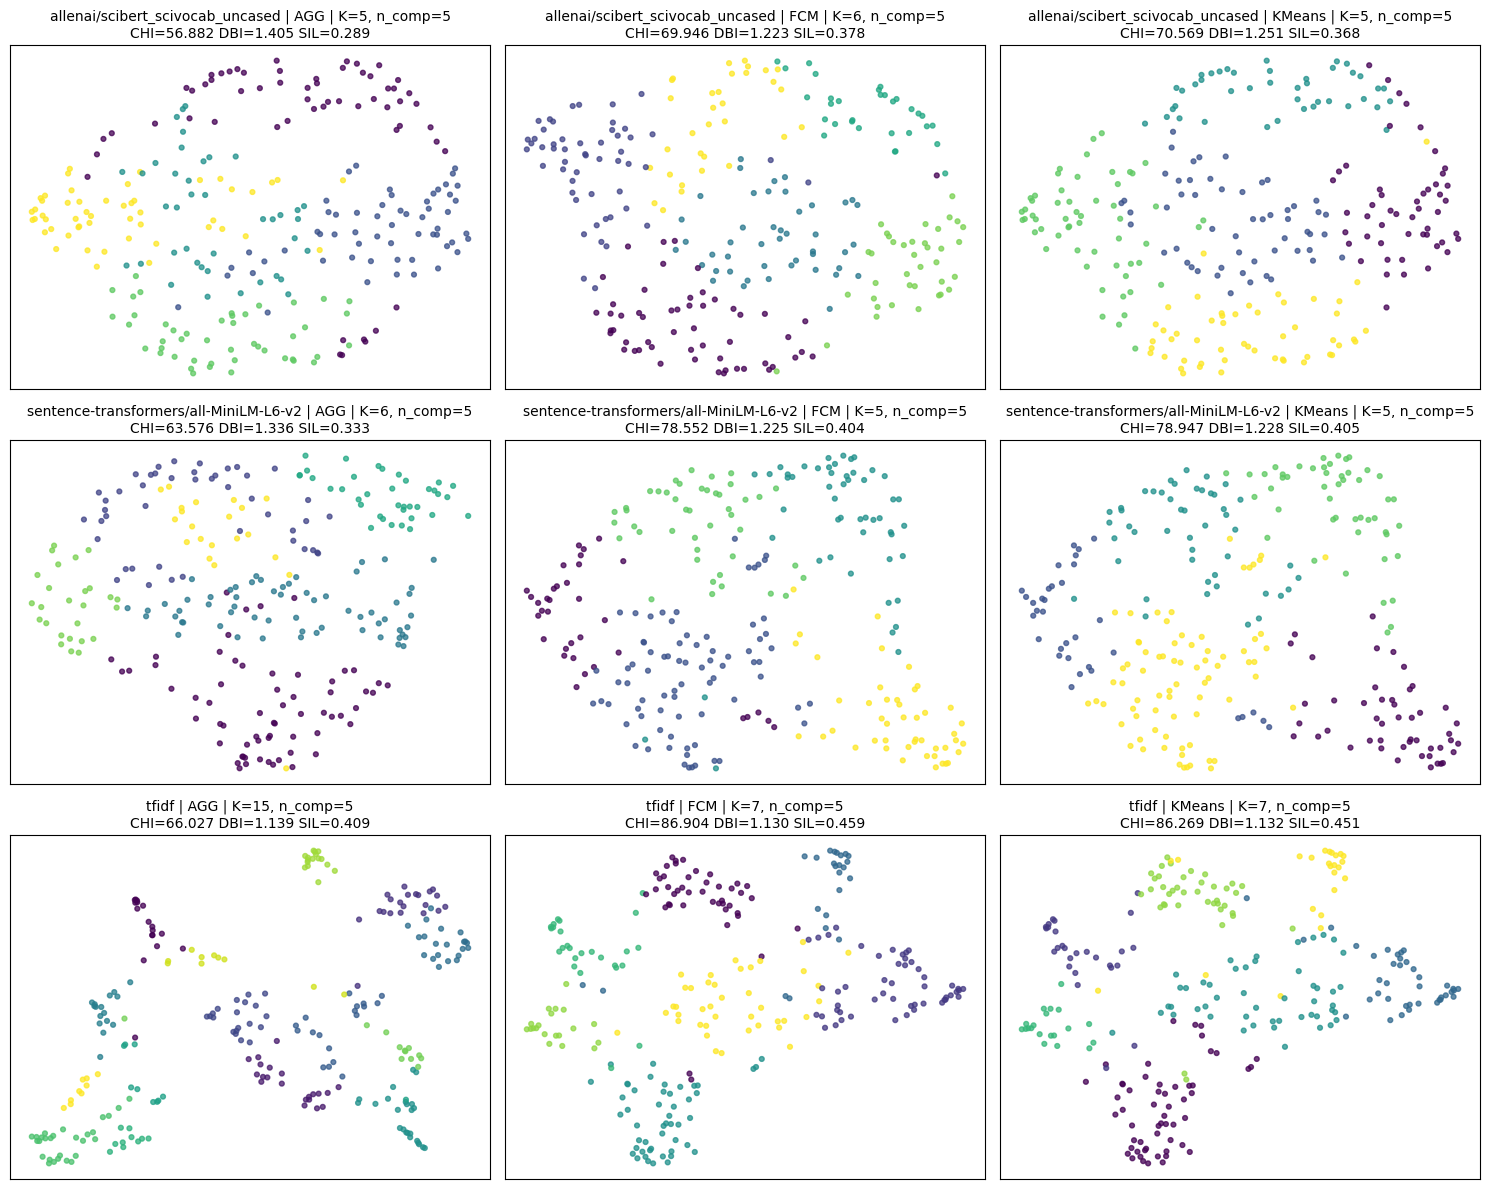

In [19]:
plot_clusters(best_per_group, texts_clean)